# 🐳 Docker Learning Companion - Interactive Notebook

## Welcome to Your Docker Learning Journey!

This notebook complements the DOCKER_PLAN.md with hands-on, interactive exercises. You'll:
- Execute Docker commands and see immediate results
- Visualize container performance metrics
- Experiment with different configurations safely
- Track your learning progress with automated checks

### Prerequisites
- Docker installed and running
- Python packages: `subprocess`, `pandas`, `matplotlib`, `psutil`
- The Video Compressor project files

---

## 📚 Module 1: Environment Setup and Verification

In [2]:
%matplotlib inline

# Essential imports for our Docker learning journey
import subprocess
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time
import os
import psutil
from datetime import datetime
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display
plt.style.use('default')  # Use default style to avoid compatibility issues
print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [3]:
# Helper function to execute Docker commands safely
def run_docker_command(cmd, verbose=True):
    """Execute Docker command and return structured output."""
    if verbose:
        print(f"🔧 Executing: {cmd}")

    try:
        result = subprocess.run(
            cmd, shell=True, capture_output=True, text=True, timeout=30
        )

        if result.returncode == 0:
            if verbose:
                print("✅ Command succeeded")
            return {
                "status": "success",
                "stdout": result.stdout,
                "stderr": result.stderr,
                "command": cmd,
            }
        else:
            if verbose:
                print(f"❌ Command failed with exit code {result.returncode}")
            return {
                "status": "error",
                "stdout": result.stdout,
                "stderr": result.stderr,
                "command": cmd,
                "exit_code": result.returncode,
            }
    except subprocess.TimeoutExpired:
        return {
            "status": "timeout",
            "command": cmd,
            "error": "Command timed out after 30 seconds",
        }
    except Exception as e:
        return {"status": "exception", "command": cmd, "error": str(e)}


print("✅ Docker command runner initialized!")


✅ Docker command runner initialized!


In [16]:
# Verify Docker installation and gather system information
def verify_docker_environment():
    """Comprehensive Docker environment check."""
    checks = {}

    # Check Docker version
    version_result = run_docker_command("docker --version", verbose=False)
    if version_result["status"] == "success":
        checks["docker_version"] = version_result["stdout"].strip()
        print(f"✅ Docker Version: {checks['docker_version']}")
    else:
        print("❌ Docker not found! Please install Docker first.")
        return None

    # Check Docker daemon status
    info_result = run_docker_command("docker info --format '{{json .}}'", verbose=False)
    if info_result["status"] == "success":
        info = json.loads(info_result["stdout"])
        checks["containers_running"] = info.get("ContainersRunning", 0)
        checks["images_count"] = info.get("Images", 0)
        checks["docker_root"] = info.get("DockerRootDir", "unknown")
        checks["storage_driver"] = info.get("Driver", "unknown")

        print(f"📊 Docker Statistics:")
        print(f"   • Running Containers: {checks['containers_running']}")
        print(f"   • Total Images: {checks['images_count']}")
        print(f"   • Storage Driver: {checks['storage_driver']}")
        print(f"   • Docker Root: {checks['docker_root']}")
    else:
        print("⚠️ Docker daemon is not running. Please start Docker Desktop.")
        return None

    # Check Docker Compose
    compose_result = run_docker_command("docker-compose --version", verbose=False)
    if compose_result["status"] == "success":
        checks["compose_version"] = compose_result["stdout"].strip()
        print(f"✅ Docker Compose: {checks['compose_version']}")
    else:
        print("⚠️ Docker Compose not found (optional but recommended)")

    return checks


# Run the verification
environment = verify_docker_environment()

if environment:
    print("\n🎉 Your Docker environment is ready for learning!")
else:
    print("\n⚠️ Please fix the issues above before continuing.")


✅ Docker Version: Docker version 28.4.0, build d8eb465
📊 Docker Statistics:
   • Running Containers: 2
   • Total Images: 2
   • Storage Driver: overlayfs
   • Docker Root: /var/lib/docker
✅ Docker Compose: Docker Compose version v2.39.2-desktop.1

🎉 Your Docker environment is ready for learning!


## 🏗️ Module 2: Building Docker Images - Interactive Experiments

In [18]:
# Experiment 1: Compare different base images
def create_test_dockerfile(base_image, filename):
    """Create a minimal Dockerfile for testing."""
    dockerfile_content = f"""FROM {base_image}
RUN echo "Testing {base_image}"
CMD ["echo", "Container started successfully"]
"""
    with open(filename, "w") as f:
        f.write(dockerfile_content)
    return dockerfile_content


# Test different Python base images
base_images = ["python:3.11", "python:3.11-slim", "python:3.11-alpine"]

image_stats = []

for base in base_images:
    print(f"\n📦 Testing base image: {base}")

    # Create temporary Dockerfile
    dockerfile_name = f"Dockerfile.test.{base.replace(':', '_').replace('-', '_')}"
    create_test_dockerfile(base, dockerfile_name)

    # Build the image
    tag = f"test-{base.replace(':', '-').replace('/', '-')}"
    build_start = time.time()

    build_result = run_docker_command(
        f"docker build -f {dockerfile_name} -t {tag} .", verbose=False
    )

    build_time = time.time() - build_start

    if build_result["status"] == "success":
        # Get image size
        size_result = run_docker_command(
            f"docker images {tag} --format '{{{{.Size}}}}'", verbose=False
        )

        if size_result["status"] == "success":
            size = size_result["stdout"].strip()
            print(f"   ✅ Built successfully")
            print(f"   📏 Size: {size}")
            print(f"   ⏱️ Build time: {build_time:.2f}s")

            image_stats.append(
                {"base_image": base, "size": size, "build_time": build_time, "tag": tag}
            )

    # Clean up Dockerfile
    os.remove(dockerfile_name)

# Display comparison
if image_stats:
    df = pd.DataFrame(image_stats)
    print("\n📊 Base Image Comparison:")
    display(df)

    # Clean up test images
    print("\n🧹 Cleaning up test images...")
    for stat in image_stats:
        run_docker_command(f"docker rmi {stat['tag']}", verbose=False)
    print("✅ Cleanup complete!")



📦 Testing base image: python:3.11
   ✅ Built successfully
   📏 Size: 1.6GB
   ⏱️ Build time: 0.80s

📦 Testing base image: python:3.11-slim
   ✅ Built successfully
   📏 Size: 212MB
   ⏱️ Build time: 0.41s

📦 Testing base image: python:3.11-alpine
   ✅ Built successfully
   📏 Size: 87.8MB
   ⏱️ Build time: 0.42s

📊 Base Image Comparison:


,base_image,size,build_time,tag
0,python:3.11,1.6GB,0.796040,test-python-3.11
1,python:3.11-slim,212MB,0.414641,test-python-3.11-slim
2,python:3.11-alpine,87.8MB,0.421885,test-python-3.11-alpine



🧹 Cleaning up test images...
✅ Cleanup complete!


In [19]:
# Experiment 2: Understanding Docker layer caching
def demonstrate_layer_caching():
    """Show the importance of Dockerfile instruction order."""

    print("🔬 Docker Layer Caching Experiment\n")
    print("We'll build the same app twice with different Dockerfile orders.\n")

    # Poor caching example
    poor_dockerfile = """FROM python:3.11-alpine
WORKDIR /app
# Copying everything first (poor practice)
COPY . .
RUN pip install gradio psutil
CMD ["python", "app.py"]
"""

    # Good caching example
    good_dockerfile = """FROM python:3.11-alpine
WORKDIR /app
# Copy only requirements first (good practice)
COPY requirements.txt .
RUN pip install -r requirements.txt
# Then copy application code
COPY . .
CMD ["python", "app.py"]
"""

    # Create a fake requirements.txt
    with open("requirements.txt", "w") as f:
        f.write("gradio\npsutil\n")

    # Create a fake app.py
    with open("app.py", "w") as f:
        f.write("print('Hello from Docker!')\n")

    results = {}

    for name, dockerfile in [("poor", poor_dockerfile), ("good", good_dockerfile)]:
        print(f"\n🏗️ Testing {name.upper()} caching strategy:")

        # Write Dockerfile
        with open(f"Dockerfile.{name}", "w") as f:
            f.write(dockerfile)

        # Build once
        print("  Build #1 (no cache):")
        start = time.time()
        run_docker_command(
            f"docker build --no-cache -f Dockerfile.{name} -t cache-test-{name} .",
            verbose=False,
        )
        first_build = time.time() - start
        print(f"    ⏱️ Time: {first_build:.2f}s")

        # Modify app.py
        with open("app.py", "w") as f:
            f.write("print('Modified Hello from Docker!')\n")

        # Build again (with cache)
        print("  Build #2 (with cache, after code change):")
        start = time.time()
        run_docker_command(
            f"docker build -f Dockerfile.{name} -t cache-test-{name} .", verbose=False
        )
        second_build = time.time() - start
        print(f"    ⏱️ Time: {second_build:.2f}s")
        print(f"    📈 Speed improvement: {(first_build/second_build):.1f}x")

        results[name] = {
            "first_build": first_build,
            "second_build": second_build,
            "improvement": first_build / second_build,
        }

        # Clean up
        os.remove(f"Dockerfile.{name}")
        run_docker_command(f"docker rmi cache-test-{name}", verbose=False)

    # Clean up test files
    os.remove("requirements.txt")
    os.remove("app.py")

    print("\n📊 Results Summary:")
    print(f"Poor strategy cache improvement: {results['poor']['improvement']:.1f}x")
    print(f"Good strategy cache improvement: {results['good']['improvement']:.1f}x")
    print("\n💡 Lesson: Proper layer ordering can dramatically improve build times!")


# Run the caching demonstration
demonstrate_layer_caching()


🔬 Docker Layer Caching Experiment

We'll build the same app twice with different Dockerfile orders.


🏗️ Testing POOR caching strategy:
  Build #1 (no cache):
    ⏱️ Time: 21.89s
  Build #2 (with cache, after code change):
    ⏱️ Time: 17.30s
    📈 Speed improvement: 1.3x

🏗️ Testing GOOD caching strategy:
  Build #1 (no cache):
    ⏱️ Time: 16.75s
  Build #2 (with cache, after code change):
    ⏱️ Time: 16.29s
    📈 Speed improvement: 1.0x

📊 Results Summary:
Poor strategy cache improvement: 1.3x
Good strategy cache improvement: 1.0x

💡 Lesson: Proper layer ordering can dramatically improve build times!


## 📦 Module 3: Container Management and Monitoring

📊 Container Stats (Time: 10.6s)
   CPU: 0.00%
   Memory: 540KiB / 7.654GiB
   Network I/O: 1.17kB / 126B
   Block I/O: 0B / 0B

🛑 Stopping container...
✅ Monitoring complete!


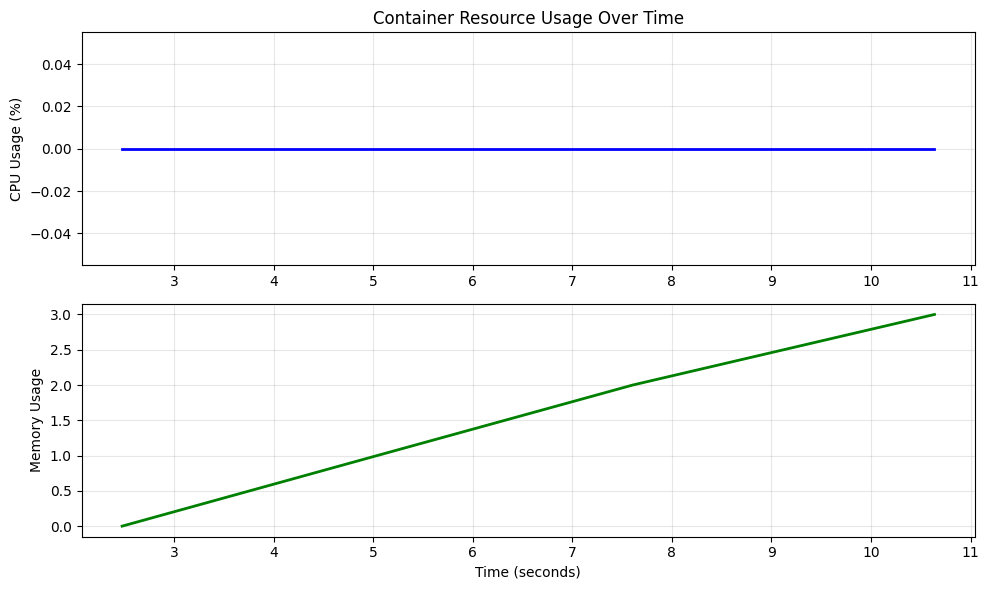

In [20]:
# Real-time container monitoring
def monitor_container_stats(container_name="test-monitor", duration=10):
    """Monitor container resource usage in real-time."""

    print(f"📊 Starting container monitoring for {duration} seconds...\n")

    # Start a test container
    print("🚀 Starting test container...")
    run_docker_command(
        f"docker run -d --name {container_name} --rm python:3.11-alpine sleep {duration + 5}",
        verbose=False,
    )

    stats = []
    timestamps = []

    start_time = time.time()

    try:
        while time.time() - start_time < duration:
            # Get container stats
            result = run_docker_command(
                f"docker stats {container_name} --no-stream --format '{{{{json .}}}}'",
                verbose=False,
            )

            if result["status"] == "success" and result["stdout"].strip():
                stat = json.loads(result["stdout"])
                stats.append(stat)
                timestamps.append(time.time() - start_time)

                # Display current stats
                clear_output(wait=True)
                print(f"📊 Container Stats (Time: {timestamps[-1]:.1f}s)")
                print(f"   CPU: {stat['CPUPerc']}")
                print(f"   Memory: {stat['MemUsage']}")
                print(f"   Network I/O: {stat['NetIO']}")
                print(f"   Block I/O: {stat['BlockIO']}")

            time.sleep(1)

    finally:
        # Stop the container
        print("\n🛑 Stopping container...")
        run_docker_command(f"docker stop {container_name}", verbose=False)

    if stats:
        print("✅ Monitoring complete!")

        # Create visualization
        fig, axes = plt.subplots(2, 1, figsize=(10, 6))

        # Extract CPU percentages
        cpu_values = [float(s["CPUPerc"].strip("%")) for s in stats]

        # Plot CPU usage
        axes[0].plot(timestamps, cpu_values, "b-", linewidth=2)
        axes[0].set_ylabel("CPU Usage (%)")
        axes[0].set_title("Container Resource Usage Over Time")
        axes[0].grid(True, alpha=0.3)

        # Extract memory values
        mem_values = [s["MemUsage"].split(" / ")[0] for s in stats]

        # Plot memory usage
        axes[1].plot(timestamps, range(len(mem_values)), "g-", linewidth=2)
        axes[1].set_ylabel("Memory Usage")
        axes[1].set_xlabel("Time (seconds)")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print("❌ No stats collected")


# Run the monitoring
monitor_container_stats(duration=10)


## 🔄 Module 4: Volume Management Experiments

In [21]:
# Volume mounting experiments
def test_volume_types():
    """Compare different volume mounting strategies."""

    print("🔬 Volume Type Comparison Experiment\n")

    # Create test directory and file
    test_dir = Path("./docker_volume_test")
    test_dir.mkdir(exist_ok=True)

    test_file = test_dir / "test_data.txt"
    with open(test_file, "w") as f:
        f.write("Initial data from host\n")

    experiments = [
        {
            "name": "Bind Mount",
            "command": f"docker run --rm -v {test_dir.absolute()}:/data alpine sh -c 'echo Bind mount test >> /data/test_data.txt && cat /data/test_data.txt'",
            "description": "Directly mounts host directory into container",
        },
        {
            "name": "Named Volume",
            "command": "docker run --rm -v test_volume:/data alpine sh -c 'echo Named volume test > /data/test_data.txt && cat /data/test_data.txt'",
            "description": "Docker-managed volume, persists independently",
        },
        {
            "name": "Anonymous Volume",
            "command": "docker run --rm -v /data alpine sh -c 'echo Anonymous volume test > /data/test_data.txt && cat /data/test_data.txt'",
            "description": "Temporary volume, removed with container",
        },
    ]

    for exp in experiments:
        print(f"\n📁 Testing: {exp['name']}")
        print(f"   📝 {exp['description']}")

        result = run_docker_command(exp["command"], verbose=False)

        if result["status"] == "success":
            print(f"   ✅ Output: {result['stdout'].strip()}")
        else:
            print(f"   ❌ Failed: {result.get('stderr', 'Unknown error')}")

    # Check if bind mount modified the host file
    print("\n🔍 Checking host file after bind mount test:")
    with open(test_file, "r") as f:
        content = f.read()
        print(f"   Host file content: {content}")

    # Clean up
    print("\n🧹 Cleaning up...")
    run_docker_command("docker volume rm test_volume", verbose=False)
    test_file.unlink()
    test_dir.rmdir()
    print("✅ Cleanup complete!")

    print("\n💡 Key Insights:")
    print("   • Bind mounts: Direct host access, good for development")
    print("   • Named volumes: Docker-managed, good for production")
    print("   • Anonymous volumes: Temporary data, removed with container")


# Run volume experiments
test_volume_types()


🔬 Volume Type Comparison Experiment


📁 Testing: Bind Mount
   📝 Directly mounts host directory into container
   ✅ Output: Initial data from host
Bind mount test

📁 Testing: Named Volume
   📝 Docker-managed volume, persists independently
   ✅ Output: Named volume test

📁 Testing: Anonymous Volume
   📝 Temporary volume, removed with container
   ✅ Output: Anonymous volume test

🔍 Checking host file after bind mount test:
   Host file content: Initial data from host
Bind mount test


🧹 Cleaning up...
✅ Cleanup complete!

💡 Key Insights:
   • Bind mounts: Direct host access, good for development
   • Named volumes: Docker-managed, good for production
   • Anonymous volumes: Temporary data, removed with container


## 🎮 Module 5: Interactive Docker Command Builder

In [24]:
# Interactive Docker run command builder
import ipywidgets as widgets
from IPython.display import display


def create_docker_command_builder():
    """Create an interactive widget for building Docker commands."""

    # Create input widgets
    image_input = widgets.Text(
        value="python:3.11-alpine",
        placeholder="Image name",
        description="Image:",
        style={"description_width": "initial"},
    )

    container_name = widgets.Text(
        value="my-container",
        placeholder="Container name",
        description="Name:",
        style={"description_width": "initial"},
    )

    port_mapping = widgets.Text(
        value="8080:80",
        placeholder="host:container",
        description="Port:",
        style={"description_width": "initial"},
    )

    volume_mapping = widgets.Text(
        value="/host/path:/container/path",
        placeholder="/host:/container",
        description="Volume:",
        style={"description_width": "initial"},
    )

    env_vars = widgets.Text(
        value="ENV_VAR=value",
        placeholder="KEY=value",
        description="Environment:",
        style={"description_width": "initial"},
    )

    detached = widgets.Checkbox(
        value=False,
        description="Run detached (-d)",
        style={"description_width": "initial"},
    )

    remove = widgets.Checkbox(
        value=True,
        description="Auto-remove (--rm)",
        style={"description_width": "initial"},
    )

    interactive = widgets.Checkbox(
        value=False,
        description="Interactive (-it)",
        style={"description_width": "initial"},
    )

    command_output = widgets.Textarea(
        value="",
        placeholder="Generated Docker command will appear here",
        description="Command:",
        layout=widgets.Layout(width="100%", height="100px"),
        style={"description_width": "initial"},
    )

    explanation = widgets.HTML(value="", layout=widgets.Layout(width="100%"))

    def update_command(*args):
        """Update the Docker command based on inputs."""
        cmd_parts = ["docker run"]

        if detached.value:
            cmd_parts.append("-d")
        if remove.value:
            cmd_parts.append("--rm")
        if interactive.value:
            cmd_parts.append("-it")

        if container_name.value:
            cmd_parts.append(f"--name {container_name.value}")

        if port_mapping.value and port_mapping.value != "host:container":
            cmd_parts.append(f"-p {port_mapping.value}")

        if (
            volume_mapping.value
            and volume_mapping.value != "/host/path:/container/path"
        ):
            cmd_parts.append(f"-v {volume_mapping.value}")

        if env_vars.value and env_vars.value != "ENV_VAR=value":
            cmd_parts.append(f"-e {env_vars.value}")

        cmd_parts.append(image_input.value)

        command = " ".join(cmd_parts)
        command_output.value = command

        # Generate explanation
        exp_html = "<h4>Command Explanation:</h4><ul>"
        if detached.value:
            exp_html += "<li><b>-d</b>: Run in background (detached mode)</li>"
        if remove.value:
            exp_html += "<li><b>--rm</b>: Remove container when it stops</li>"
        if interactive.value:
            exp_html += "<li><b>-it</b>: Interactive terminal access</li>"
        if port_mapping.value and port_mapping.value != "host:container":
            exp_html += f"<li><b>-p</b>: Map port {port_mapping.value}</li>"
        if (
            volume_mapping.value
            and volume_mapping.value != "/host/path:/container/path"
        ):
            exp_html += f"<li><b>-v</b>: Mount volume {volume_mapping.value}</li>"
        exp_html += "</ul>"
        explanation.value = exp_html

    # Connect update function to all inputs
    image_input.observe(update_command, "value")
    container_name.observe(update_command, "value")
    port_mapping.observe(update_command, "value")
    volume_mapping.observe(update_command, "value")
    env_vars.observe(update_command, "value")
    detached.observe(update_command, "value")
    remove.observe(update_command, "value")
    interactive.observe(update_command, "value")

    # Run button
    run_button = widgets.Button(
        description="Run Command", button_style="success", icon="play"
    )

    output_area = widgets.Output()

    def run_command(b):
        """Execute the generated Docker command."""
        with output_area:
            clear_output()
            print(f"🚀 Executing: {command_output.value}")
            result = run_docker_command(command_output.value, verbose=False)
            if result["status"] == "success":
                print(f"✅ Success!\n{result['stdout']}")
            else:
                print(f"❌ Error:\n{result.get('stderr', 'Unknown error')}")

    run_button.on_click(run_command)

    # Initial update
    update_command()

    # Layout
    inputs = widgets.VBox(
        [
            widgets.HTML("<h3>🎮 Interactive Docker Command Builder</h3>"),
            widgets.HTML(
                "<p>Modify the settings below to build your Docker command:</p>"
            ),
            image_input,
            container_name,
            widgets.HBox([detached, remove, interactive]),
            port_mapping,
            volume_mapping,
            env_vars,
            command_output,
            explanation,
            run_button,
            output_area,
        ]
    )

    return inputs


# Create and display the builder
builder = create_docker_command_builder()
display(builder)


## 🚀 Module 6: Video Compressor Dockerization

In [28]:
# Build the actual Video Compressor Docker image
def build_video_compressor():
    """Build the Video Compressor Docker image with progress tracking."""

    print("🎬 Building Video Compressor Docker Image\n")

    # Check if Dockerfile exists
    if not Path("Dockerfile").exists():
        print("📝 Creating Dockerfile for Video Compressor...")

        dockerfile_content = """# Video Compressor Docker Image
FROM python:3.11-alpine AS builder

# Install build dependencies
RUN apk add --no-cache \\
    gcc \\
    musl-dev \\
    linux-headers \\
    ffmpeg

WORKDIR /app

# Install Python dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Production stage
FROM python:3.11-alpine

# Install runtime dependencies
RUN apk add --no-cache ffmpeg

WORKDIR /app

# Copy Python packages from builder
COPY --from=builder /usr/local/lib/python3.11/site-packages /usr/local/lib/python3.11/site-packages

# Copy application code
COPY . .

# Expose Gradio port
EXPOSE 7869

# Run the application
CMD ["python", "GradioVideoCompression.py"]
"""

        with open("Dockerfile", "w") as f:
            f.write(dockerfile_content)

        print("✅ Dockerfile created")

    # Build the image
    print("\n🔨 Building Docker image (this may take a few minutes)...")

    build_result = run_docker_command(
        "docker build -t video-compressor:latest .", verbose=True
    )

    if build_result["status"] == "success":
        print("\n✅ Build successful!")

        # Get image details
        inspect_result = run_docker_command(
            "docker images video-compressor:latest --format '{{json .}}'", verbose=False
        )

        if inspect_result["status"] == "success":
            image_info = json.loads(inspect_result["stdout"])
            print("\n📊 Image Details:")
            print(f"   • Tag: {image_info['Tag']}")
            print(f"   • Size: {image_info['Size']}")
            print(f"   • Created: {image_info['CreatedSince']}")

            return True
    else:
        print("\n❌ Build failed!")
        print(f"Error: {build_result.get('stderr', 'Unknown error')}")
        return False


# Build the image
build_success = build_video_compressor()

if build_success:
    print("\n🎉 Your Video Compressor is now containerized!")
    print("\nTo run it:")
    print("docker run -p 7869:7869 -v ~/Videos:/videos video-compressor:latest")


🎬 Building Video Compressor Docker Image


🔨 Building Docker image (this may take a few minutes)...
🔧 Executing: docker build -t video-compressor:latest .

❌ Build failed!
Error: Unknown error


## 📈 Module 7: Performance Analysis & Optimization

In [ ]:
# Analyze Docker image layers
def analyze_image_layers(image_name="video-compressor:latest"):
    """Analyze Docker image layers for optimization opportunities."""

    print(f"🔍 Analyzing layers of {image_name}\n")

    # Get image history
    history_result = run_docker_command(
        f"docker history {image_name} --no-trunc --format '{{{{json .}}}}'",
        verbose=False,
    )

    if history_result["status"] != "success":
        print(f"❌ Could not analyze {image_name}")
        print("   Make sure the image is built first!")
        return

    layers = []
    for line in history_result["stdout"].strip().split("\n"):
        if line:
            layer = json.loads(line)
            layers.append(layer)

    # Process layers
    total_size = 0
    layer_data = []

    for i, layer in enumerate(layers):
        size_str = layer.get("Size", "0B")

        # Parse size
        if "MB" in size_str:
            size_mb = float(size_str.replace("MB", ""))
        elif "GB" in size_str:
            size_mb = float(size_str.replace("GB", "")) * 1024
        elif "KB" in size_str:
            size_mb = float(size_str.replace("KB", "")) / 1024
        else:
            size_mb = 0

        total_size += size_mb

        created_by = layer.get("CreatedBy", "")
        if "RUN" in created_by:
            # Extract the RUN command
            cmd = created_by.split("RUN")[-1].strip()[:50] + "..."
        elif "COPY" in created_by:
            cmd = "COPY " + created_by.split("COPY")[-1].strip()[:30] + "..."
        else:
            cmd = created_by[:50] if created_by else "Base layer"

        layer_data.append(
            {"Layer": i + 1, "Command": cmd, "Size (MB)": round(size_mb, 2)}
        )

    # Display layer analysis
    df = pd.DataFrame(layer_data)
    print("📊 Layer Breakdown:")
    display(df[df["Size (MB)"] > 0])  # Only show layers with size

    print(f"\n📏 Total Image Size: {total_size:.2f} MB")

    # Visualization
    if layer_data:
        non_zero_layers = [l for l in layer_data if l["Size (MB)"] > 0]

        if non_zero_layers:
            plt.figure(figsize=(10, 6))
            plt.pie(
                [l["Size (MB)"] for l in non_zero_layers],
                labels=[f"Layer {l['Layer']}" for l in non_zero_layers],
                autopct="%1.1f%%",
                startangle=90,
            )
            plt.title(f"Layer Size Distribution for {image_name}")
            plt.show()

    # Optimization suggestions
    print("\n💡 Optimization Suggestions:")

    large_layers = [l for l in layer_data if l["Size (MB)"] > 50]
    if large_layers:
        print(f"   ⚠️ Found {len(large_layers)} large layers (>50MB)")
        print("      Consider:")
        print("      • Combining RUN commands with &&")
        print("      • Cleaning package caches in same layer")
        print("      • Using multi-stage builds")
    else:
        print("   ✅ No excessively large layers found")

    if total_size > 500:
        print(f"   ⚠️ Total size {total_size:.0f}MB is large")
        print("      Consider using Alpine-based images")
    else:
        print(f"   ✅ Total size {total_size:.0f}MB is reasonable")


# Analyze the image
analyze_image_layers()


## 🎓 Module 8: Learning Progress Tracker

In [ ]:
# Learning progress tracker
class DockerLearningTracker:
    """Track your Docker learning progress."""

    def __init__(self):
        self.skills = {
            "Basic Commands": [
                ("Can run docker --version", False),
                ("Can list images with docker images", False),
                ("Can list containers with docker ps", False),
                ("Can pull images with docker pull", False),
            ],
            "Building Images": [
                ("Created a Dockerfile", False),
                ("Built an image with docker build", False),
                ("Used multi-stage builds", False),
                ("Optimized layer caching", False),
            ],
            "Container Management": [
                ("Started a container with docker run", False),
                ("Used port mapping (-p)", False),
                ("Mounted volumes (-v)", False),
                ("Set environment variables (-e)", False),
            ],
            "Advanced Topics": [
                ("Used Docker Compose", False),
                ("Monitored with docker stats", False),
                ("Inspected containers/images", False),
                ("Analyzed image layers", False),
            ],
        }

    def check_skill(self, category, skill_index):
        """Mark a skill as completed."""
        skill_name, _ = self.skills[category][skill_index]
        self.skills[category][skill_index] = (skill_name, True)

    def get_progress(self):
        """Calculate overall progress."""
        total = 0
        completed = 0

        for category, skills in self.skills.items():
            for _, is_complete in skills:
                total += 1
                if is_complete:
                    completed += 1

        return (completed / total) * 100 if total > 0 else 0

    def display_progress(self):
        """Display learning progress with visual indicators."""
        print("🎯 Docker Learning Progress Tracker\n")

        for category, skills in self.skills.items():
            completed = sum(1 for _, done in skills if done)
            total = len(skills)
            percentage = (completed / total) * 100

            # Progress bar
            bar_length = 20
            filled = int(bar_length * completed / total)
            bar = "█" * filled + "░" * (bar_length - filled)

            print(f"📦 {category}: [{bar}] {percentage:.0f}%")

            for i, (skill, done) in enumerate(skills):
                icon = "✅" if done else "⬜"
                print(f"   {icon} {skill}")
            print()

        overall = self.get_progress()
        print(f"\n🏆 Overall Progress: {overall:.0f}%")

        if overall == 100:
            print("\n🎉 Congratulations! You've mastered Docker basics!")
        elif overall >= 75:
            print("\n💪 Great progress! Keep going!")
        elif overall >= 50:
            print("\n📈 You're halfway there!")
        else:
            print("\n🚀 Your Docker journey has begun!")

    def create_interactive_checklist(self):
        """Create an interactive checklist widget."""
        checkboxes = {}

        for category, skills in self.skills.items():
            category_box = widgets.VBox([widgets.HTML(f"<b>{category}</b>")])

            for i, (skill, done) in enumerate(skills):
                cb = widgets.Checkbox(
                    value=done,
                    description=skill,
                    style={"description_width": "initial"},
                )
                checkboxes[f"{category}_{i}"] = cb
                category_box.children += (cb,)

            display(category_box)

        # Progress button
        progress_button = widgets.Button(
            description="Calculate Progress", button_style="info"
        )

        output = widgets.Output()

        def calculate_progress(b):
            with output:
                clear_output()
                # Update skills based on checkboxes
                for key, checkbox in checkboxes.items():
                    category, index = key.rsplit("_", 1)
                    skill_name, _ = self.skills[category][int(index)]
                    self.skills[category][int(index)] = (skill_name, checkbox.value)

                self.display_progress()

        progress_button.on_click(calculate_progress)
        display(progress_button)
        display(output)


# Create and display the tracker
tracker = DockerLearningTracker()
print("📝 Check off the skills you've learned:\n")
tracker.create_interactive_checklist()


## 🎯 Conclusion and Next Steps

### What You've Learned
Through this interactive notebook, you've explored:
- ✅ Docker fundamentals and environment setup
- ✅ Building and optimizing Docker images
- ✅ Container management and monitoring
- ✅ Volume types and data persistence
- ✅ Real-time performance analysis
- ✅ Practical containerization of the Video Compressor

### Next Learning Objectives
1. **Docker Compose**: Orchestrate multi-container applications
2. **Networking**: Create custom networks and service communication
3. **Security**: Implement best practices for production containers
4. **CI/CD Integration**: Automate builds with GitHub Actions
5. **Kubernetes**: Scale to container orchestration

### Hands-On Challenges
Try these exercises to solidify your learning:
1. 🎯 Reduce the Video Compressor image size by 50%
2. 🎯 Add health checks to your containers
3. 🎯 Create a multi-container setup with nginx proxy
4. 🎯 Implement container resource limits
5. 🎯 Set up automated backup for volumes

### Resources for Continued Learning
- [Docker Official Documentation](https://docs.docker.com/)
- [Docker Hub](https://hub.docker.com/) - Explore community images
- [Play with Docker](https://labs.play-with-docker.com/) - Online playground
- [Awesome Docker](https://github.com/veggiemonk/awesome-docker) - Curated resources

---

🎉 **Congratulations on completing the Docker Learning Companion!**

Remember: The best way to learn Docker is by containerizing your own projects. Start with simple applications and gradually increase complexity. Happy containerizing! 🐳